In [61]:
import aeon.io.api as aeon
import aeon.io.reader as reader
import harp
import utils
import matplotlib.pyplot as plt
import aeon.io.video as video
import pandas as pd

In [62]:
harp_reader = harp.create_reader('delphi-controller.yml', epoch=harp.REFERENCE_EPOCH)
video_reader = utils.Video()
rules_reader = utils.SessionData()
session_data_reader = utils.SessionData()

harp_datafolder = r'../temp_data/2025-10-24T15-40-23/DelphiEvents'
settings_datafolder = r'../temp_data/2025-10-24T15-40-23/HardwareSettings'
rules_datafolder = r'../temp_data/2025-10-24T15-40-23/RuleSettings'
video_datafolder = r'../temp_data/2025-10-24T15-40-23/VideoData'

In [63]:
# read experiment metadata
session_settings = utils.load_json(session_data_reader, settings_datafolder)

rule_settings = utils.load_json(rules_reader, rules_datafolder)

print(session_settings)
print(rule_settings)

                                                                     metadata
1904-01-02 18:46:42.065696  {'delphiController': {'comPort': 'COM4', 'minP...
                                                                     metadata
1904-01-02 18:46:42.065696  {'rule': {'stateDefinitions': [DotMap(name='De...


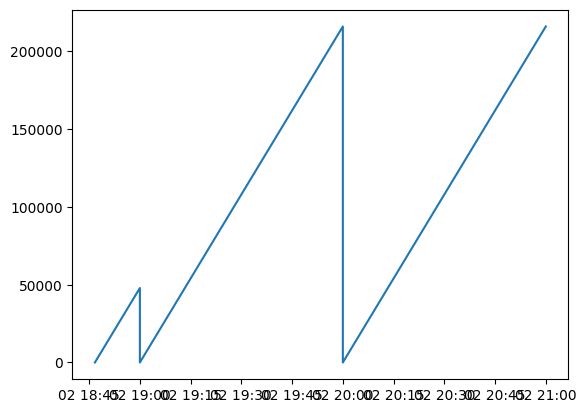

In [64]:
# read experiment video
video_data = utils.load_video(video_reader, video_datafolder)

plt.plot(video_data.index, video_data["_frame"])

In [65]:
# read controller data
poke_events = utils.load(harp_reader.PokeState, harp_datafolder)
raw_poke_events = utils.load(harp_reader.RawPokeState, harp_datafolder)

1904-01-02 18:48:22.858112


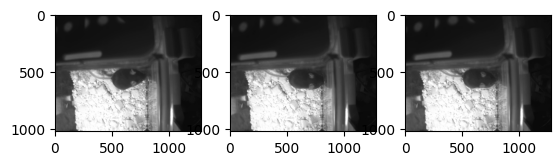

In [77]:
# example analysis centered around a particular poke event
poke_event = poke_events.index[5]
poke_event_pre = poke_event - pd.Timedelta(seconds=1)
poke_event_post = poke_event + pd.Timedelta(seconds=1)
print(poke_event)

poke_frame = [f for f in video.frames(video_data.loc[video_data.index >= poke_event].iloc[[0]])]
pre_poke_frame = [f for f in video.frames(video_data.loc[video_data.index >= poke_event_pre].iloc[[0]])]
post_poke_frame = [f for f in video.frames(video_data.loc[video_data.index >= poke_event_post].iloc[[0]])]
plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(pre_poke_frame[0])
plt.subplot(1, 3, 2)
plt.imshow(poke_frame[0])
plt.subplot(1, 3, 3)
plt.imshow(post_poke_frame[0])